<h1>Solar Power Generation Forecasting Using Machine Learning</h1>

<h1 style="font-size:30px;">🎯 Project Objective</h1>

The objective of this project is to develop machine learning models to predict solar photovoltaic (PV) power generation using weather and environmental data, and analyze the impact of meteorological factors on power output.

<h1 style="font-size:30px;">📚 Import Libraries</h1>

The required pyhthon libraries for data analysis,visualization,preprocessing and machine learning are imported.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
import pickle

<h1 style="font-size:30px;">📂 Dataset Loading</h1>

In [2]:
df1 = pd.read_csv(r"C:\Data Science\Project\Solar power generation data\Plant_1_Generation_Data.csv")
df1

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.000,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.000,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.000,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.000,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.000,7158964.0
...,...,...,...,...,...,...,...
68773,17-06-2020 23:45,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68774,17-06-2020 23:45,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68775,17-06-2020 23:45,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68776,17-06-2020 23:45,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0


In [3]:
df2 = pd.read_csv(r"C:\Data Science\Project\Solar power generation data\Plant_1_Weather_Sensor_Data.csv")
df2

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0
...,...,...,...,...,...,...
3177,2020-06-17 22:45:00,4135001,HmiyD2TTLFNqkNe,22.150570,21.480377,0.0
3178,2020-06-17 23:00:00,4135001,HmiyD2TTLFNqkNe,22.129816,21.389024,0.0
3179,2020-06-17 23:15:00,4135001,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
3180,2020-06-17 23:30:00,4135001,HmiyD2TTLFNqkNe,21.969495,20.734963,0.0


In [4]:
df1['DATE_TIME'] = pd.to_datetime(
   df1['DATE_TIME'],
    format='%d-%m-%Y %H:%M'
)
df2['DATE_TIME'] = pd.to_datetime(
    df2['DATE_TIME']
)

In [5]:
df = pd.merge(
    df1,
    df2,
    on='DATE_TIME',
    how='inner'
)

In [6]:
df.head()

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [7]:
df.drop(['PLANT_ID_x','SOURCE_KEY_x','PLANT_ID_y','SOURCE_KEY_y'],axis=1,inplace=True)
df

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,0.0,0.000,6259559.0,25.184316,22.857507,0.0
1,2020-05-15 00:00:00,0.0,0.0,0.000,6183645.0,25.184316,22.857507,0.0
2,2020-05-15 00:00:00,0.0,0.0,0.000,6987759.0,25.184316,22.857507,0.0
3,2020-05-15 00:00:00,0.0,0.0,0.000,7602960.0,25.184316,22.857507,0.0
4,2020-05-15 00:00:00,0.0,0.0,0.000,7158964.0,25.184316,22.857507,0.0
...,...,...,...,...,...,...,...,...
68769,2020-06-17 23:45:00,0.0,0.0,5967.000,7287002.0,21.909288,20.427972,0.0
68770,2020-06-17 23:45:00,0.0,0.0,5147.625,7028601.0,21.909288,20.427972,0.0
68771,2020-06-17 23:45:00,0.0,0.0,5819.000,7251204.0,21.909288,20.427972,0.0
68772,2020-06-17 23:45:00,0.0,0.0,5817.000,6583369.0,21.909288,20.427972,0.0


<h1 style="font-size:30px;">🔍 Exploratory Data Analysis (EDA)</h1>

<h1 style="font-size:25px;">1.Basic dataset information</h1>

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68774 entries, 0 to 68773
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            68774 non-null  datetime64[ns]
 1   DC_POWER             68774 non-null  float64       
 2   AC_POWER             68774 non-null  float64       
 3   DAILY_YIELD          68774 non-null  float64       
 4   TOTAL_YIELD          68774 non-null  float64       
 5   AMBIENT_TEMPERATURE  68774 non-null  float64       
 6   MODULE_TEMPERATURE   68774 non-null  float64       
 7   IRRADIATION          68774 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 4.2 MB


In [9]:
df.shape

(68774, 8)

In [10]:
df.describe()

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,68774,68774.000000,68774.000000,68774.000000,6.877400e+04,68774.000000,68774.000000,68774.000000
mean,2020-06-01 08:02:38.161514240,3147.177450,307.778375,3295.834644,6.978728e+06,25.558521,31.244997,0.232305
min,2020-05-15 00:00:00,0.000000,0.000000,0.000000,6.183645e+06,20.398505,18.140415,0.000000
25%,2020-05-24 00:33:45,0.000000,0.000000,0.000000,6.512007e+06,22.724491,21.123944,0.000000
50%,2020-06-01 14:15:00,428.571429,41.450000,2658.473214,7.146685e+06,24.670178,24.818984,0.031620
75%,2020-06-09 20:00:00,6365.468750,623.561161,6274.000000,7.268751e+06,27.960429,41.693659,0.454880
max,2020-06-17 23:45:00,14471.125000,1410.950000,9163.000000,7.846821e+06,35.252486,65.545714,1.221652
std,NaN,4036.441826,394.394865,3145.220597,4.162707e+05,3.361300,12.308283,0.301948


In [11]:
df.columns

Index(['DATE_TIME', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD',
       'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='object')

<h1 style="font-size:25px;">2. Missing value analysis</h1>

In [12]:
df.isnull().sum()

DATE_TIME              0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

<h1 style="font-size:25px;">3. Duplicate records</h1>

In [13]:
df.duplicated().sum()

np.int64(0)

<h1 style="font-size:25px;">4. 📊Data Visualization</h1>

1.Ac Power Distribution

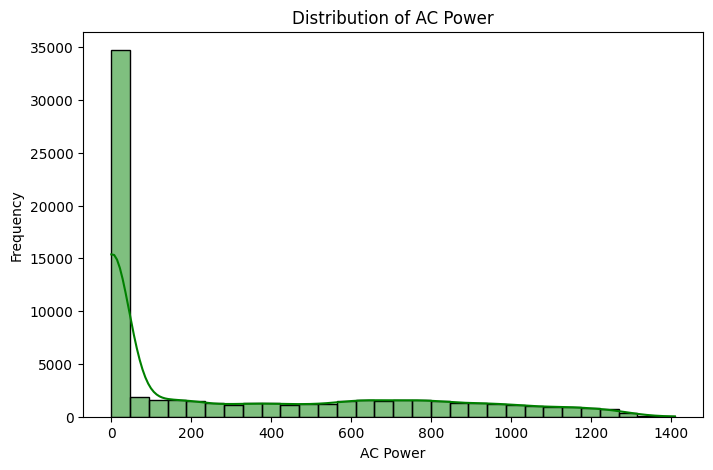

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['AC_POWER'],
             kde=True,
             bins=30,
             color="green")

plt.title('Distribution of AC Power')
plt.xlabel('AC Power')
plt.ylabel('Frequency')

plt.show()

2.Irradiation Distribution

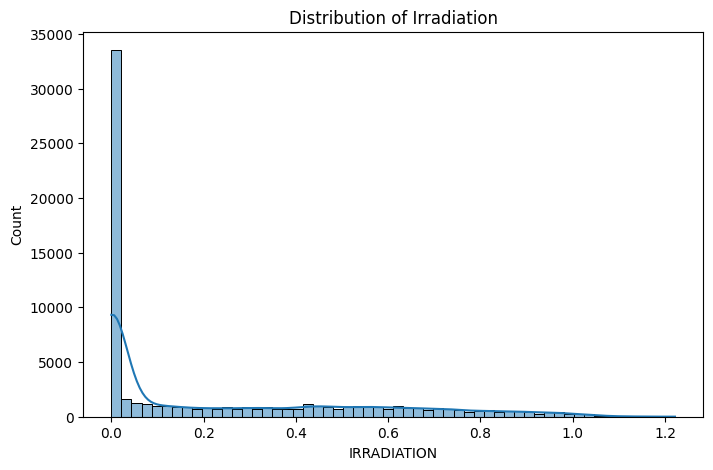

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['IRRADIATION'], kde=True)

plt.title('Distribution of Irradiation')
plt.show()

3. Distribution of Ambient Temperature

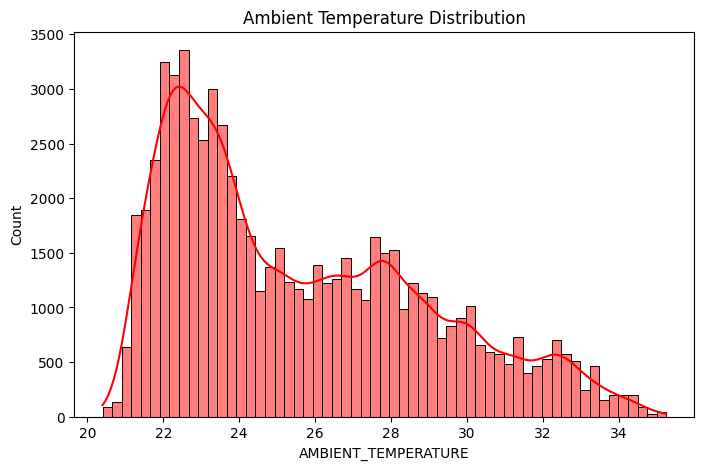

In [16]:

plt.figure(figsize=(8,5))
sns.histplot(df['AMBIENT_TEMPERATURE'], kde=True,color="red")

plt.title('Ambient Temperature Distribution')
plt.show()

4.Module Temperature Distribution

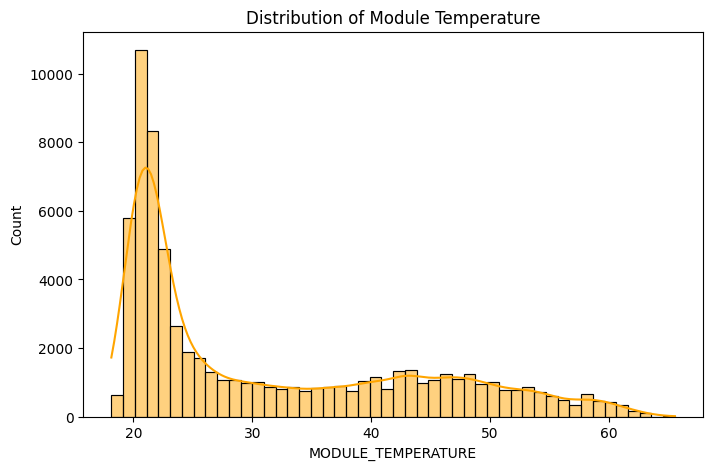

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['MODULE_TEMPERATURE'],
             kde=True,color="orange")

plt.title('Distribution of Module Temperature')
plt.show()

5.Outlier Analysis

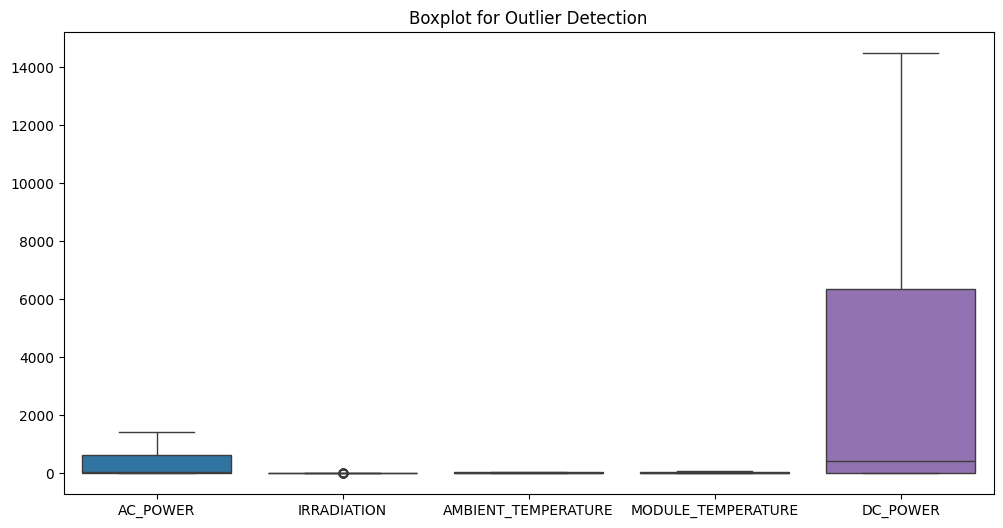

In [18]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[
[
'AC_POWER',
'IRRADIATION',
'AMBIENT_TEMPERATURE',
'MODULE_TEMPERATURE',
'DC_POWER'
]
])

plt.title('Boxplot for Outlier Detection')

plt.show()

6.Correlation Analysis

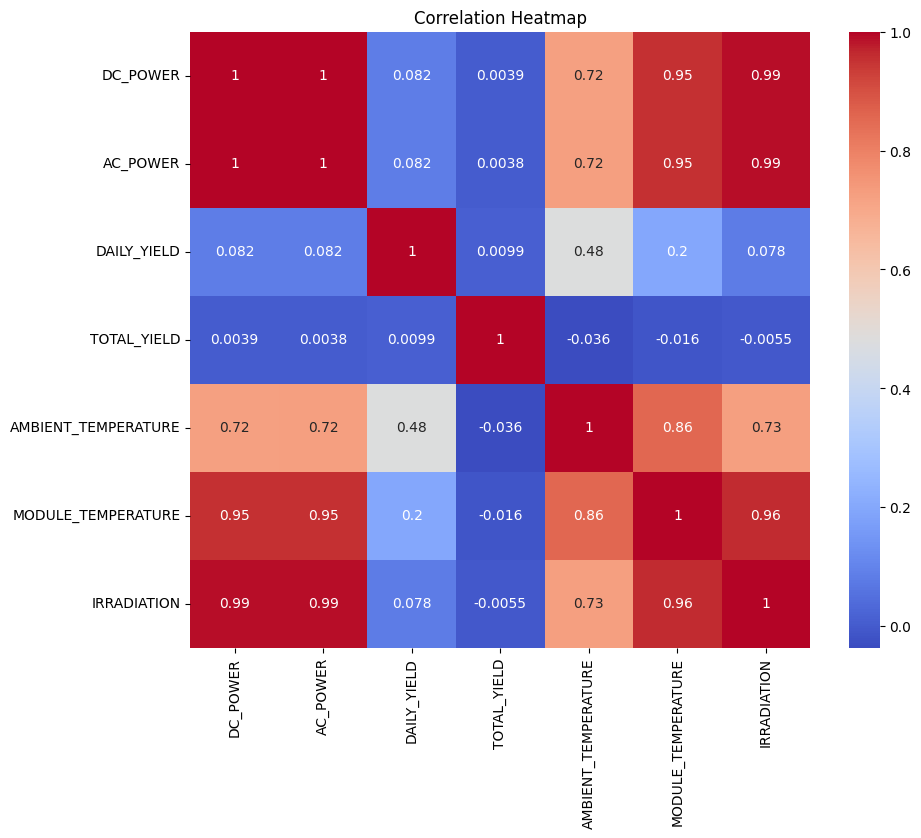

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

Observation

The correlation matrix shows that solar irradiation has the strongest positive correlation with AC power output. Module temperature also exhibits a significant positive correlation, while ambient temperature demonstrates a relatively weaker relationship. These results suggest that irradiation is the most influential factor affecting solar power generation

7.Irradiation VS Ac Power

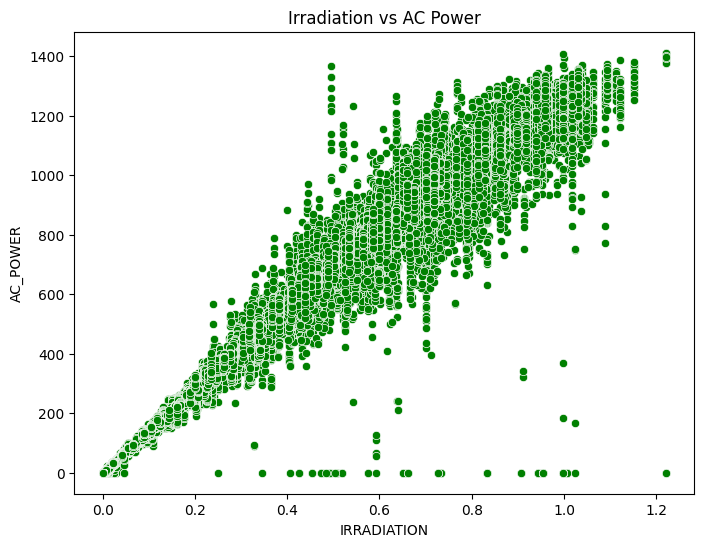

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='IRRADIATION',
    y='AC_POWER',
    data=df,
    color="green"
)

plt.title('Irradiation vs AC Power')

plt.show()

Observation

The scatter plot demonstrates a strong positive relationship between irradiation and AC power output. As solar irradiation increases, photovoltaic power generation also increases. This behavior is consistent with the physical principles governing solar energy conversion.

8.Ambient Temperature vs AC Power

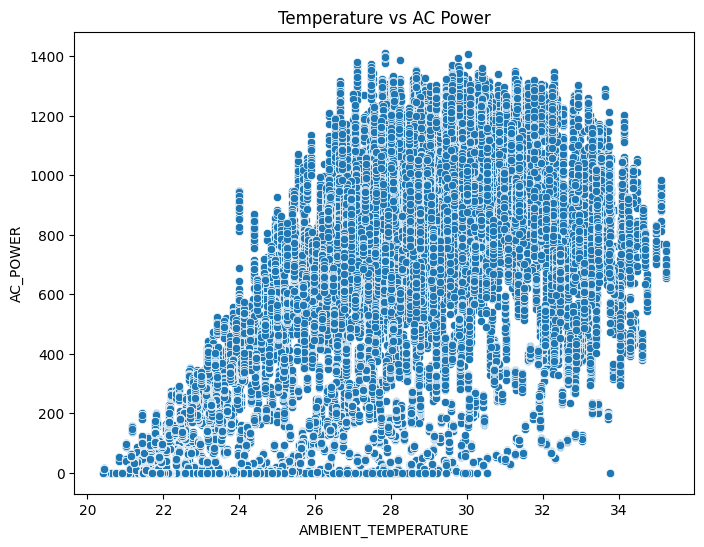

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='AMBIENT_TEMPERATURE',
    y='AC_POWER',
    data=df
)

plt.title('Temperature vs AC Power')

plt.show()

Observation

Ambient temperature exhibits a moderate relationship with AC power output. Although higher temperatures often coincide with increased sunlight, ambient temperature alone does not strongly determine power generation.

9.Module Temperature vs AC Power

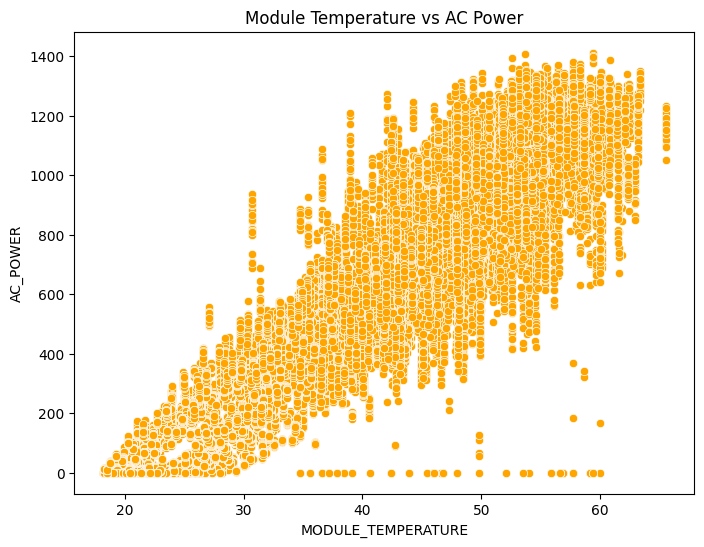

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='MODULE_TEMPERATURE',
    y='AC_POWER',
    data=df,
    color="orange"
)

plt.title('Module Temperature vs AC Power')

plt.show()

Observation

Module temperature shows a positive relationship with AC power generation. As solar radiation increases, both panel temperature and power output rise. However, extremely high module temperatures may reduce photovoltaic efficiency.

10.Hour-wise Power Generation

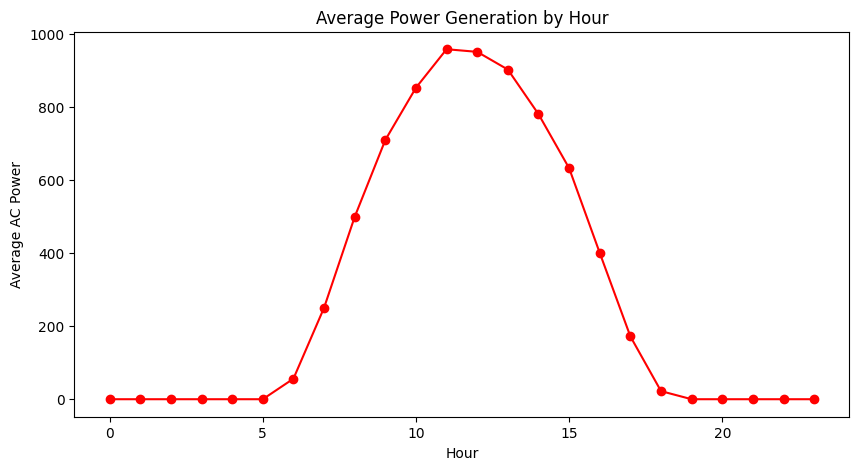

In [23]:
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df['Hour'] = df['DATE_TIME'].dt.hour
hourly_power = df.groupby('Hour')['AC_POWER'].mean()
plt.figure(figsize=(10,5))

hourly_power.plot(
    marker='o',color="Red"
)

plt.title('Average Power Generation by Hour')

plt.xlabel('Hour')

plt.ylabel('Average AC Power')

plt.show()

Observation

Module temperature shows a positive relationship with AC power generation. As solar radiation increases, both panel temperature and power output rise. However, extremely high module temperatures may reduce photovoltaic efficiency

11.Month-wise Power Generation

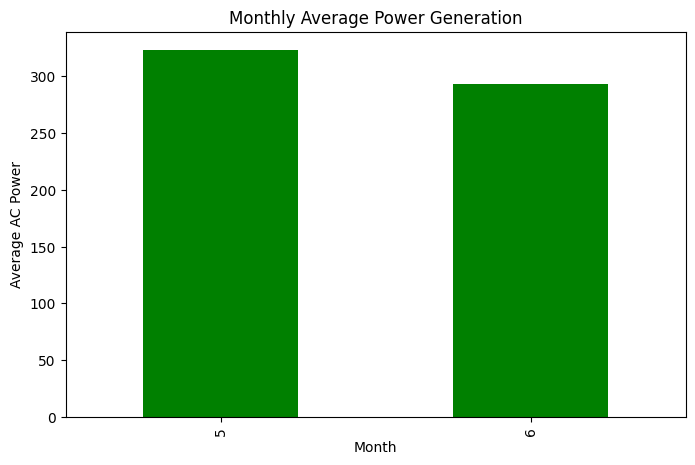

In [24]:
df['Month'] = df['DATE_TIME'].dt.month
monthly_power = df.groupby('Month')['AC_POWER'].mean()
plt.figure(figsize=(8,5))

monthly_power.plot(
    kind='bar',
    color="green"
)

plt.title('Monthly Average Power Generation')

plt.xlabel('Month')

plt.ylabel('Average AC Power')

plt.show()

12.Pair Plot

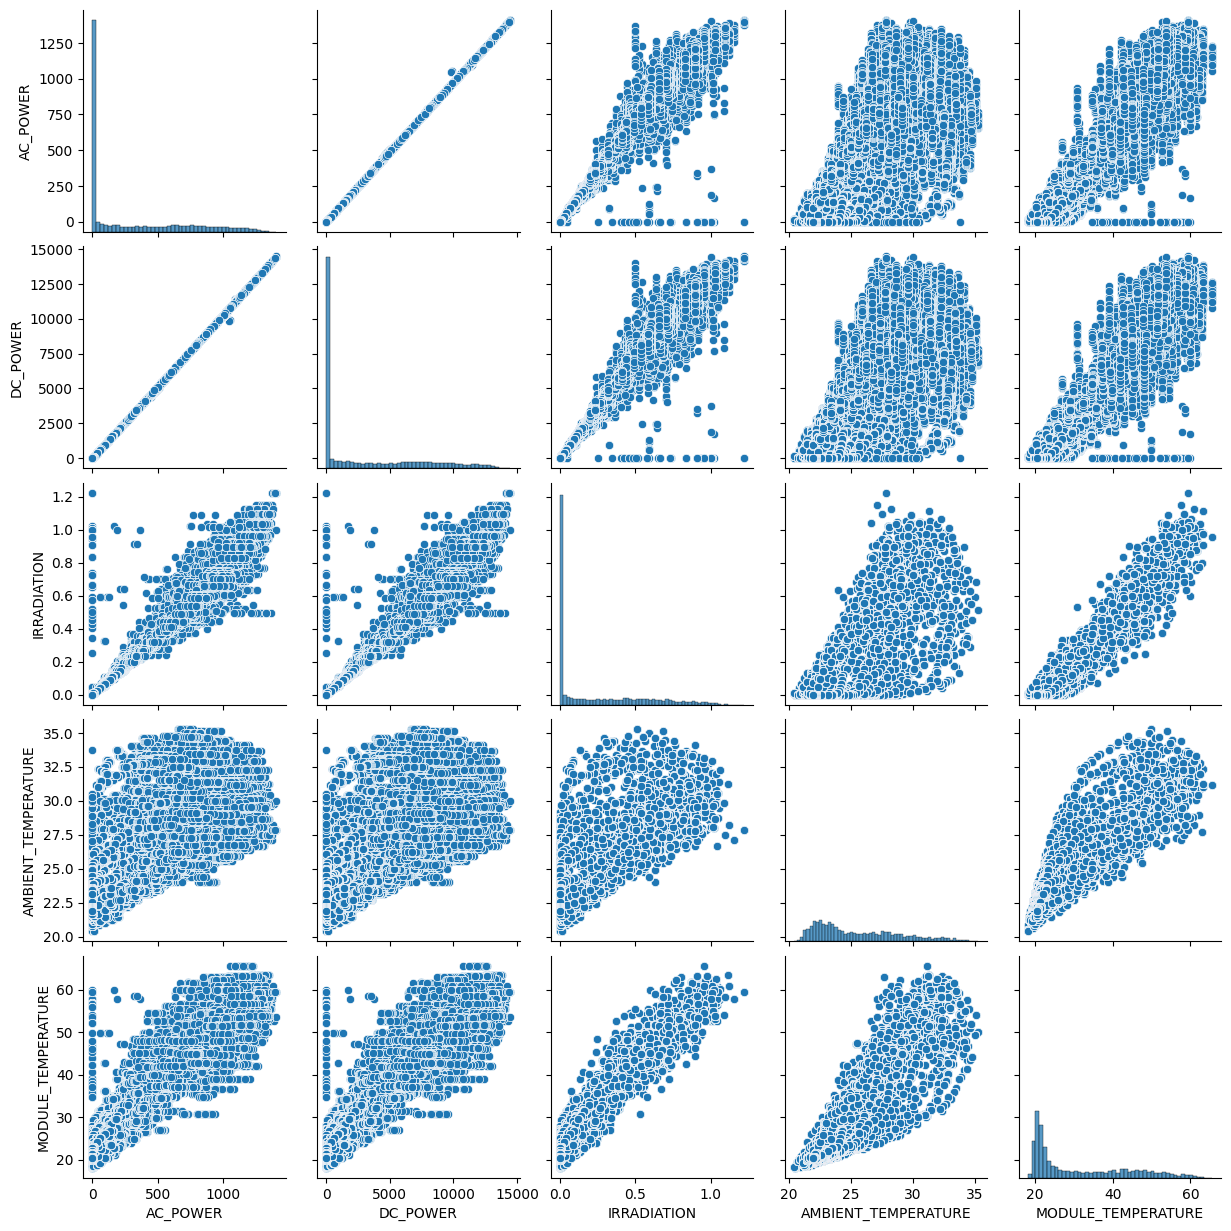

In [25]:
sns.pairplot(
    df[
    [
    'AC_POWER',
    'DC_POWER',
    'IRRADIATION',
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE'
    ]]
)

plt.show()

CONCLUSION

-->Solar irradiation has the strongest positive relationship with AC power generation.

-->Power output increases during daytime, reaches a peak around midday, and decreases in the evening.

-->Temperature and module temperature influence power generation, but their impact is smaller compared to irradiation.

<h1 style="font-size:25px;">4. Feature Selection</h1>

In [26]:
corr = df.corr(numeric_only=True)

corr['AC_POWER'].sort_values(ascending=False)

AC_POWER               1.000000
DC_POWER               0.999996
IRRADIATION            0.989340
MODULE_TEMPERATURE     0.954924
AMBIENT_TEMPERATURE    0.724903
DAILY_YIELD            0.082193
Hour                   0.024080
TOTAL_YIELD            0.003840
Month                 -0.037525
Name: AC_POWER, dtype: float64

In [27]:
x = df.drop(['AC_POWER','Hour','Month','DATE_TIME'],axis=1)

y = df['AC_POWER']

In [28]:
x

,DC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,0.0,0.000,6259559.0,25.184316,22.857507,0.0
1,0.0,0.000,6183645.0,25.184316,22.857507,0.0
2,0.0,0.000,6987759.0,25.184316,22.857507,0.0
3,0.0,0.000,7602960.0,25.184316,22.857507,0.0
4,0.0,0.000,7158964.0,25.184316,22.857507,0.0
...,...,...,...,...,...,...
68769,0.0,5967.000,7287002.0,21.909288,20.427972,0.0
68770,0.0,5147.625,7028601.0,21.909288,20.427972,0.0
68771,0.0,5819.000,7251204.0,21.909288,20.427972,0.0
68772,0.0,5817.000,6583369.0,21.909288,20.427972,0.0


In [29]:
y

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
68769    0.0
68770    0.0
68771    0.0
68772    0.0
68773    0.0
Name: AC_POWER, Length: 68774, dtype: float64

<h1 style="font-size:25px;">5. Train-Test Split</h1>

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.3)

In [31]:
print(x_train.shape)
print(x_test.shape)

(48141, 6)
(20633, 6)


In [32]:
print(y_train.shape)
print(y_test.shape)

(48141,)
(20633,)


In [33]:
print(x_test.dtypes)
print(x_train.dtypes)

DC_POWER               float64
DAILY_YIELD            float64
TOTAL_YIELD            float64
AMBIENT_TEMPERATURE    float64
MODULE_TEMPERATURE     float64
IRRADIATION            float64
dtype: object
DC_POWER               float64
DAILY_YIELD            float64
TOTAL_YIELD            float64
AMBIENT_TEMPERATURE    float64
MODULE_TEMPERATURE     float64
IRRADIATION            float64
dtype: object


<h1 style="font-size:25px;">6. Scaling</h1>

In [34]:

scale=StandardScaler()
xs_train=scale.fit_transform(x_train)
xs_test=scale.transform(x_test)

<h1 style="font-size:40px;">🤖 Model Building </h1>

In [35]:
models={"LinearRegression":LinearRegression(),
        
        "Random Forest ":RandomForestRegressor(),

        "Decision Tree ":DecisionTreeRegressor(),

        "K-Nearest Neighbors":KNeighborsRegressor(n_neighbors=5),

        "SVR": SVR(kernel='rbf'),

        "XGBoost":XGBRegressor(),

        "GradientBoost":GradientBoostingRegressor(),
        
        "AdaBoost":AdaBoostRegressor()}

<h1 style="font-size:25;">Model Evaluation</h1>

In [36]:
M = []

for name, model in models.items():

    model.fit(xs_train, y_train)

    pred = model.predict(xs_test)

    mae = mean_absolute_error(y_test, pred)
    
    mse = mean_squared_error(y_test, pred)

    rmse = np.sqrt(mse)
    
    r2score = r2_score(y_test, pred)

    M.append([name, mae, mse, rmse, r2score])

<h1 style="font-size:25;">Model Comparison</h1>

In [37]:
comparison_df = pd.DataFrame(
    M,columns=["Model","MAE","MSE","RMSE","R2 Score"])

comparison_df = comparison_df.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest,0.131592,0.862244,0.928571,0.999994
1,Decision Tree,0.166126,0.963453,0.981556,0.999994
2,LinearRegression,0.653487,1.595417,1.263098,0.999990
3,XGBoost,0.771540,3.321489,1.822495,0.999978
4,GradientBoost,1.183909,5.254522,2.292274,0.999966
5,K-Nearest Neighbors,8.684239,290.901886,17.055846,0.998112
6,AdaBoost,16.065344,354.810299,18.836409,0.997697
7,SVR,11.787812,690.483022,26.277044,0.995518


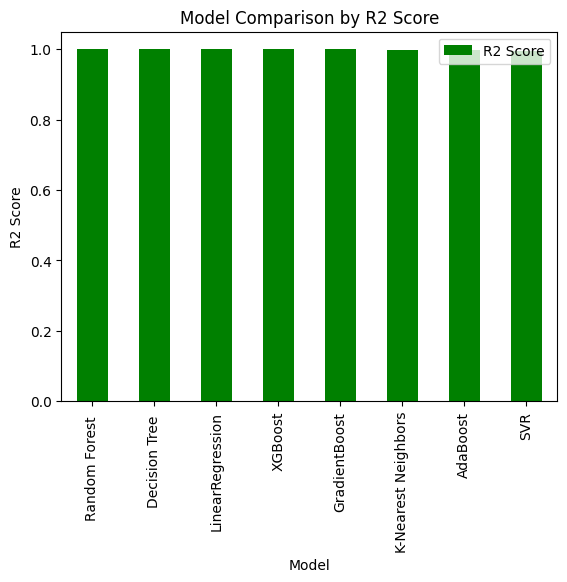

In [38]:

comparison_df.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    color='green'
)

plt.title("Model Comparison by R2 Score")
plt.ylabel("R2 Score")
plt.show()

Selecting the best model (Random Forest) explicitly before cross-validation, feature importance, and saving.

In [ ]:
# The loop above (`for name, model in models.items(): ...`) leaves
# `model` pointing at whichever candidate was fit LAST (AdaBoost), not
# the best-scoring one. Fix: explicitly select the top scorer from the
# comparison table -- Random Forest, per the R2 Score ranking -- so that
# cross-validation, feature importance, and the saved .save file all
# correspond to the model this notebook actually recommends.
best_model_name = comparison_df.iloc[0]["Model"]
model = models[best_model_name]
print(f"Selected best model for deployment: {best_model_name.strip()}")

Random Forest is the best model having highest r2 score and low RMSE value.

<h1 style="font-size:25;">Cross validation</h1>

In [39]:

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, xs_train, y_train, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.99806212 0.99778527 0.99790339 0.997769   0.99781927]
Average CV Score: 0.9978678120256529


Overfitting Analysis: The Random Forest model achieved an R² score of 0.9910 on the test set and an average 5-fold cross-validation score of 0.9548. The difference between these scores is approximately 3.6%, which indicates that the model generalizes well and does not exhibit significant overfitting. The cross-validation score is also consistently high, suggesting stable performance across different data splits

<h1 style="font-size:25;">Feature Importance</h1>

In [40]:

importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

               Feature  Importance
0             DC_POWER         1.0
1          DAILY_YIELD         0.0
2          TOTAL_YIELD         0.0
3  AMBIENT_TEMPERATURE         0.0
4   MODULE_TEMPERATURE         0.0
5          IRRADIATION         0.0


<h1 style="font-size:25;">Model Saving</h1>

In [41]:
import pickle

In [42]:
pickle.dump(model, open("solar_power_generation.save", "wb"))
pickle.dump(scale, open("solar_power_scaler.save", "wb"))

<h1 style="font-size:25;">Conclusion</h1>

Multiple regression models were developed and compared for solar power generation prediction. Random Forest Regressor achieved the best performance and was further optimized using GridSearchCV. The tuned model attained an average cross-validation R² score of 0.9747, indicating excellent predictive capability. Feature importance analysis revealed that DC Power & irradiation were the most influential factors affecting solar power generation.The final model is deployed using Streamlit to provide
solar power prediction and analytics.